# Technology for Energy systems integration - Final Assignment
## Energy transition study with integration of multiple energy carriers

### POINT 1: Design of renewable production, electricity transmission and storage for given demand and constraints

#### Provided code 

In [1]:
# Import packages

import pandas as pd
import numpy as np
import requests
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import pvlib
import openpyxl
from scipy.optimize import linprog
import pypsa
import calendar

In [2]:
# Given information from group_list:
node_lat = 56.6225
node_lon = 9.6218
node_alt = 0

distance12 = 43

electricity_demand_multiplier = 0.959773112
heat_demand_multiplier = 0.98067983

In [3]:
# Create time series with hourly resolution for the given period
year = 2011
month = 4
times = pd.date_range(start='2011-04-01', end='2011-04-30 23:00:00', freq='h', tz='Europe/Amsterdam')

# Check (Includes 720 timesteps) 
print(times)

DatetimeIndex(['2011-04-01 00:00:00+02:00', '2011-04-01 01:00:00+02:00',
               '2011-04-01 02:00:00+02:00', '2011-04-01 03:00:00+02:00',
               '2011-04-01 04:00:00+02:00', '2011-04-01 05:00:00+02:00',
               '2011-04-01 06:00:00+02:00', '2011-04-01 07:00:00+02:00',
               '2011-04-01 08:00:00+02:00', '2011-04-01 09:00:00+02:00',
               ...
               '2011-04-30 14:00:00+02:00', '2011-04-30 15:00:00+02:00',
               '2011-04-30 16:00:00+02:00', '2011-04-30 17:00:00+02:00',
               '2011-04-30 18:00:00+02:00', '2011-04-30 19:00:00+02:00',
               '2011-04-30 20:00:00+02:00', '2011-04-30 21:00:00+02:00',
               '2011-04-30 22:00:00+02:00', '2011-04-30 23:00:00+02:00'],
              dtype='datetime64[ns, Europe/Amsterdam]', length=720, freq='h')


In [4]:
# Function to import climate data from JRC - DO NOT CHANGE

def import_jrc_climate_data(lon: float, lat: float, year: int | str, alt: float) -> dict:
    """
    Reads in climate data for a full year from `JRC PVGIS <https://re.jrc.ec.europa.eu/pvg_tools/en/>`_.

    :param float lon: longitude of node - the api will read data for this location
    :param float lat: latitude of node - the api will read data for this location
    :param int year: optional, needs to be in range of data available. If nothing is specified, a typical year \
    will be loaded
    :param float alt: altitude of location specified
    :return: dict containing information on the location (altitude, longitude, latitude and a dataframe \
    containing climate data (ghi = global horizontal irradiance, dni = direct normal irradiance, \
    dhi = diffuse horizontal irradiance, rh = relative humidity, temp_air = air temperature, ws = wind speed at \
    specified hight. Wind speed is returned as a dict for different heights.
    :rtype: dict
    """

    # Specify year import, lon, lat
    parameters = {"lon": lon, "lat": lat, "year": year, "outputformat": "json"}
    time_index = pd.date_range(
        start=str(year) + "-01-01 00:00", end=str(year) + "-12-31 23:00", freq="1h"
    )

    # Get data from JRC dataset
    answer = dict()
    print("Importing Climate Data...")
    response = requests.get("https://re.jrc.ec.europa.eu/api/tmy?", params=parameters)
    if response.status_code == 200:
        print("Importing Climate Data successful")
    else:
        raise Exception(response)
    data = response.json()
    climate_data = data["outputs"]["tmy_hourly"]

    # Compile return dict
    answer["longitude"] = lon
    answer["latitude"] = lat
    answer["altitude"] = alt

    ghi = []
    dni = []
    dhi = []
    rh = []
    temp_air = []
    wind_speed = dict()
    wind_speed["10"] = []

    for t_interval in climate_data:
        ghi.append(t_interval["G(h)"])
        dni.append(t_interval["Gb(n)"])
        dhi.append(t_interval["Gd(h)"])
        rh.append(t_interval["RH"])
        temp_air.append(t_interval["T2m"])
        wind_speed["10"].append(t_interval["WS10m"])

    answer["dataframe"] = pd.DataFrame(
        np.array([ghi, dni, dhi, temp_air, rh]).T,
        columns=["ghi", "dni", "dhi", "temp_air", "rh"],
        index=time_index,
    )
    for ws in wind_speed:
        answer["dataframe"]["ws" + str(ws)] = wind_speed[ws]

    return answer

In [5]:
# Import climate data

climate_data = import_jrc_climate_data(node_lon, node_lat, year, node_alt)

Importing Climate Data...
Importing Climate Data successful


In [6]:
# Create wind turbine power curve function - DO NOT CHANGE
name = "WindTurbine_Onshore_4000"
wt_data_path = 'data/WT_data.csv'
wt_data_full = pd.read_csv(wt_data_path, delimiter=";")
# match WT with data
wt_data = wt_data_full[wt_data_full["TurbineName"] == name]
hubheight = 120

# Make power curve
rated_capacity = wt_data.iloc[0]["RatedPowerkW"]
wind_speed = np.linspace(0, 35, 71)
power_output = wt_data.iloc[:, 13:84]
power_output = power_output.to_numpy()

f = interp1d(wind_speed, power_output)

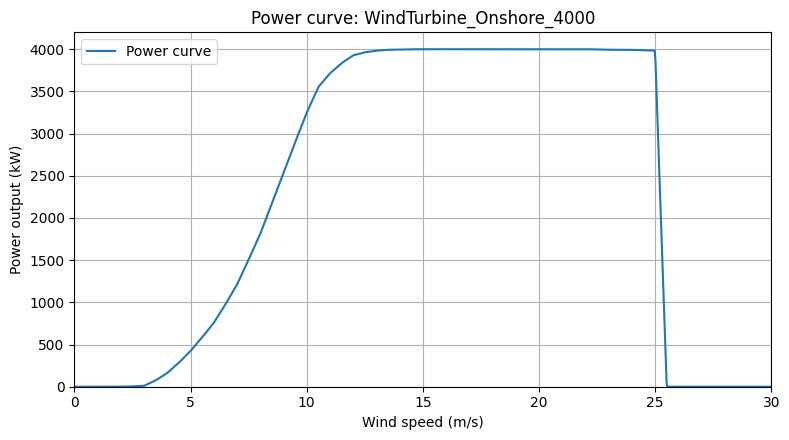

In [7]:
# Vizualize power curve

x_plot = np.linspace(0, 30, 1000)
y_plot = f(x_plot).ravel()

plt.figure(figsize=(8, 4.5))
plt.plot(x_plot, y_plot, label="Power curve")
plt.xlabel("Wind speed (m/s)")
plt.ylabel("Power output (kW)")
plt.title(f"Power curve: {name}")
plt.legend()
plt.grid(True)
plt.xlim(0, 30)
plt.ylim(0, max(float(rated_capacity) * 1.05, power_output.max() * 1.05))
plt.tight_layout()
plt.show()

In [8]:
# Weather data - DO NOT CHANGE
df = climate_data['dataframe']

if "ws100" in df.columns:
    ws = df["ws100"]
    ws_height = 100
else:
    ws = df["ws10"]
    ws_height = 10

alpha = 1/7

if hubheight > 0:
    ws = ws * (hubheight / ws_height) ** alpha

In [9]:
# defining pv data - DO NOT CHANGE

pv_system_data = dict()
pv_system_data["tilt"] = 18
pv_system_data["surface_azimuth"] = 180
pv_system_data["module_name"] = "SunPower_SPR_X20_327"
pv_system_data["inverter_eff"] = 0.96

inverter_parameters = {
    "pdc0": 5000,
    "eta_inv_nom": pv_system_data["inverter_eff"],
}

In [10]:
# Fitting pv system - DO NOT CHANGE
module_database = pvlib.pvsystem.retrieve_sam("CECMod")
module = module_database[pv_system_data["module_name"]]

temperature_model_parameters = (
    pvlib.temperature.TEMPERATURE_MODEL_PARAMETERS["sapm"][
        "open_rack_glass_glass"
    ]
)

# Create PV model chain
inverter_parameters = {
    "pdc0": 5000,
    "eta_inv_nom": pv_system_data["inverter_eff"],
}

system = pvlib.pvsystem.PVSystem(
    surface_tilt=pv_system_data["tilt"],
    surface_azimuth=pv_system_data["surface_azimuth"],
    module_parameters=module,
    inverter_parameters=inverter_parameters,
    temperature_model_parameters=temperature_model_parameters,
)

# Get location
tz = 'Europe/Amsterdam'

location = pvlib.location.Location(node_lat, node_lon, tz=tz, altitude=node_alt)

pv_model = pvlib.modelchain.ModelChain(
    system, location, spectral_model="no_loss", aoi_model="physical"
)
peakpower = module.STC

In [11]:
# Energy production

# Hours to skip to reach the selected month
skip_hours = sum(calendar.monthrange(year, m)[1] for m in range(1, month)) * 24

# wind capacity factor
capacity_factor_wind = f(np.clip(ws.values, 0, 35)) / 4000
capacity_factor_wind = pd.Series(
    np.asarray(capacity_factor_wind).flatten()[skip_hours:skip_hours + len(times)],
    index=times
)

# solar capacity factor
pv_model.run_model(df)
power = pv_model.results.ac.p_mp
capacity_factor_solar = power / peakpower

capacity_factor_solar = pd.Series(
    np.asarray(capacity_factor_solar).flatten()[skip_hours:skip_hours + len(times)],
    index=times
)

C:\Users\hp\anaconda3\envs\pypsa_esi\Lib\site-packages\scipy\optimize\_chandrupatla.py:437: RuntimeWarning:

invalid value encountered in divide



#### 1. Input Data

##### 1.1 Capacity factor 

The hourly capacity factor for Denmark in April 2011 are shown in the graph. Wind and solar availability seem to overlap during several periods, notably around 4th, 8th, from the 15th to the 20th, and again near th 24th and 28th of the month. During these moments, electricity supply is high, becuase both technologies produce strongly at the same time, which can increase the likehood of renewable energy curtailment. On average, wind capacity factors are higher than solar. Wind generation is more continous and contibutes more energy over the month than solar. Solar capacity factors have sharper and shorter peaks, but also drop to zero more frequently becuase of the day and night cycle. 


Summary statistics for hourly capacity factors in April 2011
          Wind    Solar
count  720.000  720.000
mean     0.192    0.122
std      0.201    0.205
min      0.000   -0.000
25%      0.034   -0.000
50%      0.139   -0.000
75%      0.278    0.171
max      0.973    0.787

Average capacity factors in April 2011
Wind  : 0.192
Solar : 0.122

Sum of hourly capacity factors over the month
Wind  : 138.04
Solar : 87.72


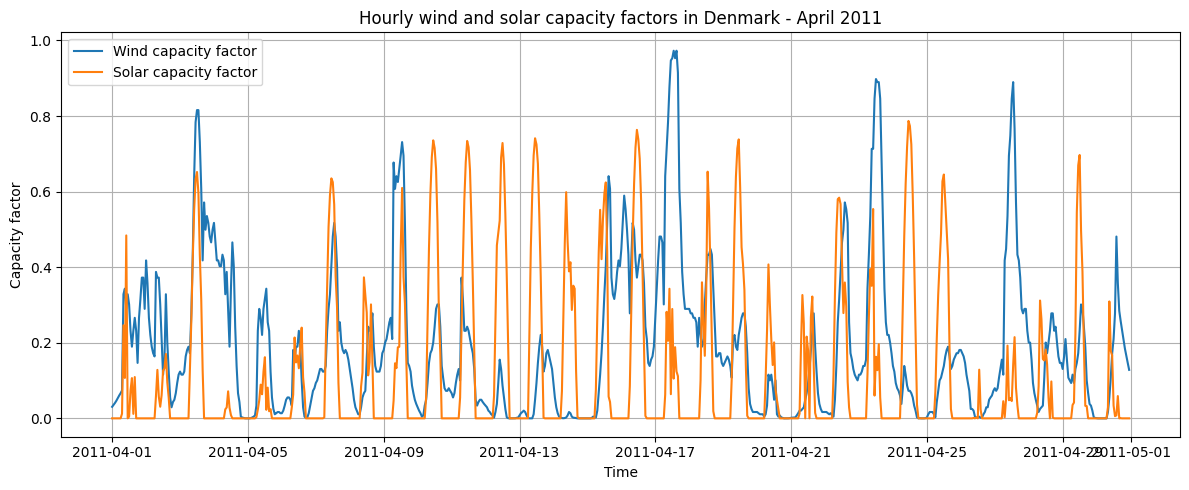

In [12]:
# Monthly summary statistics
cf_summary = pd.DataFrame({
    "Wind": capacity_factor_wind,
    "Solar": capacity_factor_solar
}).describe()

print("\nSummary statistics for hourly capacity factors in April 2011")
print(cf_summary.round(3))

# Average capacity factors over April
avg_wind_cf = capacity_factor_wind.mean()
avg_solar_cf = capacity_factor_solar.mean()

print("\nAverage capacity factors in April 2011")
print(f"Wind  : {avg_wind_cf:.3f}")
print(f"Solar : {avg_solar_cf:.3f}")

# Optional: total monthly capacity factor sum
print("\nSum of hourly capacity factors over the month")
print(f"Wind  : {capacity_factor_wind.sum():.2f}")
print(f"Solar : {capacity_factor_solar.sum():.2f}")

# Plot of hourly capacity factors for the full month
plt.figure(figsize=(12, 5))

plt.plot(capacity_factor_wind.index, capacity_factor_wind, label='Wind capacity factor')
plt.plot(capacity_factor_solar.index, capacity_factor_solar, label='Solar capacity factor')

plt.xlabel('Time')
plt.ylabel('Capacity factor')
plt.title('Hourly wind and solar capacity factors in Denmark - April 2011')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



##### 1.2 Electricity and heat demand 

The graphs show electrcity and heat demand for industrial and residential Zone 2 over a period of month and first 96 hours. Overall, heat demand is much higher than electricity demand, averaging at around 86 MWh. Electricity demand is much lower at approximately 28 MWh. Electricity demand shows a strong dialy pattern, with clear peaks, reflecting day and night consumption. Heat demand is much smoother and gradully changes over time.  

In [13]:
# Electricity and Heat demand data
import calendar

skip = sum(calendar.monthrange(year, m)[1] for m in range(1, month)) * 24

demand_data_path = 'data/demand_production.xlsx'

df_p1 = pd.read_excel(demand_data_path, sheet_name='Point1', header=1)

el_demand = df_p1['Electricity [MWh]'].iloc[skip : skip + len(times)].reset_index(drop=True).astype(float)
el_demand = el_demand * electricity_demand_multiplier
el_demand.index = times

heat_demand = df_p1['Heat [MWh]'].iloc[skip : skip + len(times)].reset_index(drop=True).astype(float)
heat_demand = heat_demand * heat_demand_multiplier
heat_demand.index = times

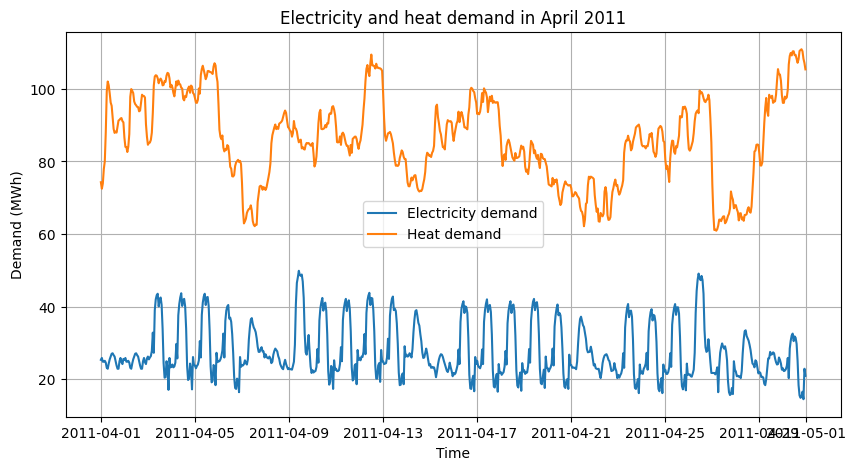

Average electricity demand: 27.71 MWh
Average heat demand       : 85.95 MWh


In [14]:
plt.figure(figsize=(10,5))

plt.plot(el_demand, label="Electricity demand")
plt.plot(heat_demand, label="Heat demand")

plt.xlabel("Time")
plt.ylabel("Demand (MWh)")
plt.title("Electricity and heat demand in April 2011")

plt.legend()
plt.grid(True)
plt.show()

avg_el = el_demand.mean()
avg_heat = heat_demand.mean()

print(f"Average electricity demand: {avg_el:.2f} MWh")
print(f"Average heat demand       : {avg_heat:.2f} MWh")

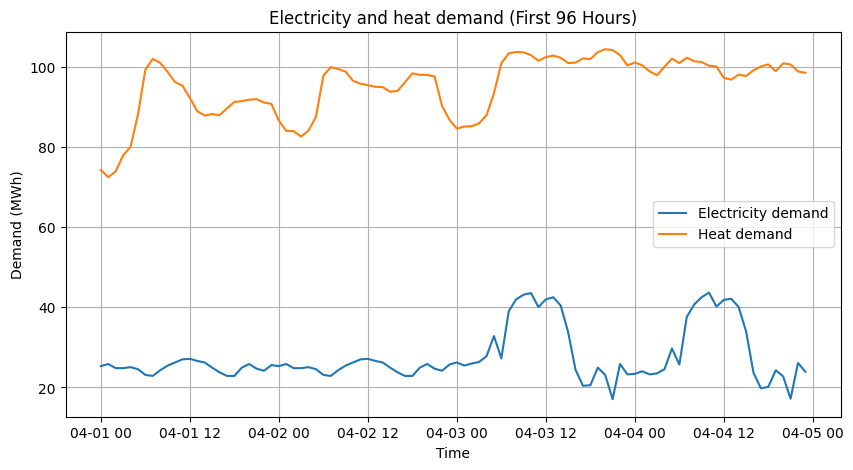

In [15]:
plt.figure(figsize=(10,5))

plt.plot(el_demand.iloc[:96], label="Electricity demand")
plt.plot(heat_demand.iloc[:96], label="Heat demand")

plt.xlabel("Time")
plt.ylabel("Demand (MWh)")
plt.title("Electricity and heat demand (First 96 Hours)")

plt.legend()
plt.grid(True)
plt.show()

##### 1.3 Techno-economic data

The techno-economic data are provided in an Excel sheet, extracted using a defined function and summarized in an overview. From the data, wind appears to be much more expensive than solar, while also having a shorter lifetime. The battery stands out as the most expensive technology, due to its moderately high capex, very high opex, and shorter lifetime. Zone 2 can import electrcity at a cost of 150 EUR/MWh, with a maximum of 25 MWh per hour. The penalty for unserved demand is 1500 EUR/MWh, which is really high. This storngly discourages unmet demand and ensures that the system will prioritize supplying elelctrcity even at highh cost. 

In [16]:
# Obtaining techno-economic data

tech_eco_data_path = 'data/technoeconomic_data.xlsx'
tech_eco_data = pd.read_excel(tech_eco_data_path, sheet_name='Data', header=2)

def get_value(df, component, data_type):
    mask = (df['component'] == component) & (df['parameter'] == data_type)
    result = df.loc[mask, 'value']
    if len(result) == 0:
        raise ValueError(f"No data found for component='{component}', parameter='{data_type}'")
    return result.values[0]

# We give you the wind turbine techno-economic data import as example. Save all the relevant data with the same function
# !!Make sure to use the correct units!!

In [17]:
# Wind turbine
Wind_capex = get_value(tech_eco_data, 'Wind turbine', 'Investment cost') * 1000  # EUR/MW
Wind_lifetime = get_value(tech_eco_data, 'Wind turbine', 'Lifetime')  # year
Wind_opex = get_value(tech_eco_data, 'Wind turbine', 'Opex') / 100  # % capex/year

#Solar PV
PV_capex = get_value(tech_eco_data, 'Solar panel', 'Investment cost') * 1000  # EUR/MW
PV_lifetime = get_value(tech_eco_data, 'Solar panel', 'Lifetime') # year
PV_opex = get_value(tech_eco_data, 'Solar panel', 'Opex') / 100 # % capex/year

# Battery is a 2-hour battery because max charge/discharge power = 50% of energy size
Battery_max_charge = get_value(tech_eco_data, 'Li-ion battery', 'Max charging capacity') / 100 
Battery_max_hours = 1 / Battery_max_charge

#Li-ion Battery
Battery_capex = get_value(tech_eco_data, 'Li-ion battery', 'Investment cost') * 1000 * Battery_max_hours # EUR/MW
Battery_lifetime = get_value(tech_eco_data, 'Li-ion battery', 'Lifetime') # year
Battery_opex = get_value(tech_eco_data, 'Li-ion battery', 'Opex') / 100 # % capex/year
Battery_charge_eff = get_value(tech_eco_data, 'Li-ion battery', 'Charging efficiency') / 100 # MW
Battery_discharge_eff = get_value(tech_eco_data, 'Li-ion battery', 'Discharging efficiency') / 100 # MW
Battery_max_discharge = get_value(tech_eco_data, 'Li-ion battery', 'Max discharging capacity') / 100
Battery_self_discharge = get_value(tech_eco_data, 'Li-ion battery', 'Self-discharge coefficient') /100

#Electricity Cable
Line_capex_km = get_value(tech_eco_data, 'Electricity cable', 'Investment cost') #EUR/kW/km
Line_capex = get_value(tech_eco_data, 'Electricity cable', 'Investment cost') * 1000 * distance12 # EUR/MW
Line_lifetime = get_value(tech_eco_data, 'Electricity cable', 'Lifetime')
Line_opex = get_value(tech_eco_data, 'Electricity cable', 'Fixed Opex') / 100
Line_losses_per_100km = get_value(tech_eco_data, 'Electricity cable', 'Losses') / 100

#Market Assumptions
Unserved_penalty = get_value(tech_eco_data, 'Operational cost', 'Lost load penalty') # EUR/MWh
Import_limit = get_value(tech_eco_data, 'Operational cost', 'Max import availability') # MWh
Import_price = get_value(tech_eco_data, 'Operational cost', 'Electricity import cost') # EUR/MWh

#Discount Rate Assumptions
discount_rate = 0.05

#Transmission Quantities
line_loss_fraction = Line_losses_per_100km * (distance12 / 100.0)
line_efficiency = 1 - line_loss_fraction



# Data summary
all_input_data = pd.DataFrame({
    "Technology": ["Wind", "Solar", "Cable", "Battery"],
    "Capex Cost (EUR/MW)": [
        Wind_capex,
        PV_capex,
        Line_capex,
        Battery_capex
    ],
    "Lifetime (years)": [
        Wind_lifetime,
        PV_lifetime,
        Line_lifetime,
        Battery_lifetime
    ],
    "Opex (% of capex/year)": [
        Wind_opex * 100,
        PV_opex * 100,
        Line_opex * 100,
        Battery_opex * 100
    ]
})

title = "Technology input data overview"
print(f"\n{title}")
print("=" * len(title))
print(all_input_data.round(2).to_string(index=False))

print("\nAdditional battery parameters")
print("=============================")
print(f"Charging efficiency           : {Battery_charge_eff:.2%}")
print(f"Discharging efficiency        : {Battery_discharge_eff:.2%}")
print(f"Max charging capacity         : {Battery_max_charge:.2%} of energy capacity per hour")
print(f"Max discharging capacity      : {Battery_max_discharge:.2%} of energy capacity per hour")
print(f"Self discharge                : {Battery_self_discharge:.4%}")
print(f"Battery max hours             : {Battery_max_discharge:.2f} hour")

print("\nElectricity cable parameters")
print("===========================")
print(f"Transmission efficiency       : {line_efficiency:.2%}")
print(f"Transmission losses           : {line_loss_fraction:.2%}")

print("\nMarket assumptions")
print("==================")
print(f"Lost load penalty             : {Unserved_penalty:,.2f} EUR/MWh")
print(f"Maximum import availability   : {Import_limit:,.2f} MW")
print(f"Electricity import cost       : {Import_price:,.2f} EUR/MWh")


Technology input data overview
Technology  Capex Cost (EUR/MW)  Lifetime (years)  Opex (% of capex/year)
      Wind            1180000.0              27.0                     2.0
     Solar             560000.0              35.0                     2.0
     Cable             193930.0              40.0                     2.5
   Battery             580000.0              15.0                     8.4

Additional battery parameters
Charging efficiency           : 98.00%
Discharging efficiency        : 97.00%
Max charging capacity         : 50.00% of energy capacity per hour
Max discharging capacity      : 50.00% of energy capacity per hour
Self discharge                : 0.0040%
Battery max hours             : 0.50 hour

Electricity cable parameters
Transmission efficiency       : 97.85%
Transmission losses           : 2.15%

Market assumptions
Lost load penalty             : 1,500.00 EUR/MWh
Maximum import availability   : 25.00 MW
Electricity import cost       : 150.00 EUR/MWh


#### 2. Converting Input Data

This code converts input data of capex, opex, life3time into regular monthly capital costs required for Pypsa. The annuity factor speads the investment over its lifetime, while accounting for the docisount rate, returning equivalent yearly costs. Fixed annual opex is than added to obtain the total yearly cost. Finally, this total is divided by 12 to express the cost on a monthly basis. Using our function, the monthly fixed cost per MW is calculated for each technology. 
                                                                                                          

In [18]:
# Compute annuity factor using discount rate and lifetime
def annuity_factor(r, n):
    return r / (1 - (1+r) ** (-n))

# Compute monthly fixed cost from CAPEX and OPEX
def monthly_fixed_cost(capex_per_unit, lifetime, opex_frac=0.0, discount_rate=0.05):

    # Convert upfront CAPEX into yearly payments
    annualized_capex = capex_per_unit * annuity_factor(discount_rate, lifetime)
    # Compute yearly fixed OPEX cost
    annual_opex = capex_per_unit * opex_frac
    # Convert total yearly cost to monthly costs 
    return(annualized_capex + annual_opex) / 12

wind_capital_cost = monthly_fixed_cost(
    Wind_capex, Wind_lifetime, Wind_opex, discount_rate
)

PV_capital_cost = monthly_fixed_cost(
    PV_capex, PV_lifetime, PV_opex, discount_rate
)

line_capital_cost = monthly_fixed_cost(
    Line_capex, Line_lifetime, Line_opex, discount_rate
)

battery_capital_cost = monthly_fixed_cost(
    Battery_capex, Battery_lifetime, Battery_opex, discount_rate
)

print("Monthly Fixed Capital Cost (EUR/MW/month)")
print(f"Wind:    €{wind_capital_cost:,.2f}")
print(f"PV:      €{PV_capital_cost:,.2f}")
print(f"Cable:   €{line_capital_cost:,.2f}")
print(f"Battery: €{battery_capital_cost:,.2f}")


Monthly Fixed Capital Cost (EUR/MW/month)
Wind:    €8,682.03
PV:      €3,783.35
Cable:   €1,345.84
Battery: €8,716.54


#### 3. Creating Pypsa network

To model the system, a Pypsa network is used, which allows for the simulation and optimization of electricity systems using built-in software feastures. 

The function builds network by setting hourly snapshots for April 2011. The model represents two zones (buses) connected by a transmission cable. For each generator, capacity factors and capital costs were specifed.Zone 1 includes renewable energy generation from wind and solar. Zone 2 contains electricity demand, grid imports (with a maxmimum import limit and import price), the option of lost load (unserved demand), represented by a high penalty cost. 

The transmittion line the zones is modeled with transmission efficiency, capital costs and 10MW increments for modeled capacity. A battery storage unit is also included, with the option to place it either Zone 1 or Zone 2. The battery is modeled using charge, discharge, while accounting for state of charge balance. 

Finally, the optimization is run for both battery locations to compare system performance. 

In [19]:
# Define time snapshot
times_pypsa = pd.date_range(start='2011-04-01', end='2011-04-30 23:00:00', freq='h')

# Define a function 
def network_part1(storage_location=None): 

    # Create an empty energy system model
    n = pypsa.Network() 
    
    # Set the time steps over which the model runs 
    n.set_snapshots(times_pypsa) 

    # Set equal snapshot weights so each timestep counts as 1 hour
    n.snapshot_weightings.loc[:, "objective"] = 1.0
    n.snapshot_weightings.loc[:, "stores"] = 1.0
    if "generators" in n.snapshot_weightings.columns:
        n.snapshot_weightings.loc[:, "generators"] = 1.0

    # Create buses (nodes where electricty flows in and out), representing two regions connected by a transmission line
    n.add("Bus", "zone1_el", carrier="electricity")
    n.add("Bus", "zone2_el", carrier="electricity")

    # Generators in Zone 1
    
    # Wind farm
    n.add(
        "Generator", # Pypsa component type: electricity generation
        "wind", # Name of the generator 
        bus="zone1_el", # Connected to electricity bus in Zone 1
        carrier="wind", # Technology type 
        p_nom_extendable = True, # The optimizer can choose the installed capacity
        p_nom_min = 0, # Minimum installed capacity is 0 MW
        p_max_pu = np.asarray(capacity_factor_wind).flatten(), # Hourly availability profile as a fraction of installed capacity
        marginal_cost = 0.0, # No marginal generation cost assumed for wind (no fuel cost)
        capital_cost = wind_capital_cost # Annualized i nvestment cost per MW of installed capacity
    )
    
    # Solar PV 
    n.add(
        "Generator",
        "solar",
        bus="zone1_el",
        carrier = "solar",
        p_nom_extendable = True,
        p_nom_min = 0,
        p_max_pu = np.asarray(capacity_factor_solar).flatten(),
        marginal_cost = 0.0,
        capital_cost = PV_capital_cost
    )

    # Electricity demand in Zone 2
    n.add(
        "Load", # Pypsa component type for electricity consumption 
        "demand", # Variable name
        bus = "zone2_el", # Location
        p_set = np.asarray(el_demand).flatten() # Hourly demand profile
    )

    # External import in Zone 2
    n.add(
        "Generator",
        "grid_import",
        bus = "zone2_el", # Imports are injected into the electricity bus in Zone 2
        carrier = "import", # Label for imported electricity 
        p_nom = Import_limit, # Maximum import capacity (up tp 25 MW in any hour)
        p_nom_extendable = False, # Import capacity is fixed
        marginal_cost = Import_price # Cost per MWh of imported electricity (EUR/MWh)
    )

    # Lost load in Zone 2 (represents unserved demand at a high-cost generator)
    # If the system cannot meet demand, this component supplies the missing energy at a very high penalty cost
    n.add(
        "Generator",
        "lost_load",
        bus="zone2_el", # Injected at the demand location (Zone 2)
        carrier = "lost_load",
        p_nom = 5*np.max(el_demand), # Set capacity much larger than anything realistically needed
        p_nom_extendable = False, # Capacity is fixed (no need to optimize)
        marginal_cost = Unserved_penalty # Penalty cost for unserved demand (EUR/MWh)
    )

    # Transmission line from Zone 1 to Zone 2
    n.add(
        "Link", # Link represents directed energy transfer between two buses
        "line12",
        bus0 = "zone1_el", # Orgin of electricity
        bus1 = "zone2_el", # Destination
        carrier = "electricity_link",
        efficiency = line_efficiency, # Transmission line efficiency is 0.95
        p_nom_extendable = True, # Solver chooses capacity
        p_nom_min = 0, # Minimum capacity
        p_nom_max = 500, # Maximum capacity 
        p_nom_mod = 10, # 10 MW increments
        marginal_cost = 0.0, # No variable cost
        capital_cost = line_capital_cost # Investment cost per MW
        )

    # Battery location option
    battery_bus = "zone1_el" if storage_location == "zone1" else "zone2_el"

    # Battery
    n.add(
        "StorageUnit", # Pypsa built-in battery model
        "battery",
        bus = battery_bus, # Connects location to the battery
        carrier = "battery",
        p_nom_extendable = True, 
        p_nom_min = 0, 
        p_nom_max = 500, # Abstract large max capacity 
        max_hours = Battery_max_hours, # Energy to power ratio (2 hours storage)
        efficiency_store = Battery_charge_eff, # Charging efficiency 
        efficiency_dispatch = Battery_discharge_eff, # Discharging efficiency 
        standing_loss = Battery_self_discharge, # Hourly self-discharge
        marginal_cost = 0.0, 
        capital_cost = battery_capital_cost,
        cyclic_state_of_charge = True # SOC(end) = SOC(start)
    )

    return n

Case 1: Battery in Zone 1

In [20]:
# Run the optimization model with battery located in Zone 1

n_zone1 = network_part1(storage_location="zone1")

status, condition = n_zone1.optimize(solver_name="highs")

print("\n OPTIMIZATION STATUS ")
print("Status   :", status)
print("Condition:", condition)

Index(['zone1_el', 'zone2_el'], dtype='object', name='name')
Index(['wind', 'solar', 'grid_import', 'lost_load'], dtype='object', name='name')
Index(['line12'], dtype='object', name='name')
Index(['battery'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.19s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 5765 primals, 13687 duals
Objective: 2.43e+06
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.



 OPTIMIZATION STATUS 
Status   : ok
Condition: optimal


Case 2: Battery in Zone 2

In [21]:
# Run the optimization model with battery located in Zone 2

n_zone2 = network_part1(storage_location="zone2")

status, condition = n_zone2.optimize(solver_name="highs")

print("\n OPTIMIZATION STATUS ")
print("Status   :", status)
print("Condition:", condition)

Index(['zone1_el', 'zone2_el'], dtype='object', name='name')
Index(['wind', 'solar', 'grid_import', 'lost_load'], dtype='object', name='name')
Index(['line12'], dtype='object', name='name')
Index(['battery'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.14s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 5765 primals, 13687 duals
Objective: 2.43e+06
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.



 OPTIMIZATION STATUS 
Status   : ok
Condition: optimal


#### 4. Extracting Results

This section defines a function to extract key performance indicators (KPIs) from the optimized Pypsa network. It collects main model resuts like installed capacities and generetion. It calulates system operation indicators like imports, unserved demand, renewable curtailment, transmitted electricity, transmission losses, line utilization, and the battery state of charge. 

In [22]:
# Extract Key Performance Indicators from Pypsa network 
def KPI_part1(n, storage_location=None):

    # Installed capacities (MW)
    # These are the optimal capacities chosen by the solver
    wind_capacity = n.generators.at["wind", "p_nom_opt"]
    solar_capacity = n.generators.at["solar", "p_nom_opt"]
    line_capacity = n.links.at["line12", "p_nom_opt"]
    battery_capacity = n.storage_units.at["battery", "p_nom_opt"]

    # Battery energy capacity (MWh)
    # Energy capacity = power capacity * max hours
    battery_energy = battery_capacity * n.storage_units.at["battery", "max_hours"]

    # Generation over time (MW)
    # Hourly dispatch of each component    
    wind_generation = n.generators_t.p["wind"]
    solar_generation = n.generators_t.p["solar"]
    import_ts = n.generators_t.p["grid_import"]
    lost_load_ts = n.generators_t.p["lost_load"]

    # Hourly dispatch for solar and wind 
    res_generation = wind_generation + solar_generation

    # Transmission flows 
    # Power sent from zone 1 to zone 2
    # Power recieved accounts for transmission efficiency 
    line12_send = n.links_t.p0["line12"].abs()
    line12_receive = line12_send * n.links.at["line12", "efficiency"]

    # Electricity market managment 
    # Available = installed capacity * capacity factors     
    wind_available = wind_capacity * np.asarray(capacity_factor_wind).flatten()
    solar_available = solar_capacity * np.asarray(capacity_factor_solar).flatten()
    res_available = pd.Series(wind_available + solar_available, index=times_pypsa)

    # Curtailment (MWh)  
    curtailment = (res_available - res_generation).clip(lower=0)

    # Battery state of charge (SOC)
    # Stored energy over time 
    battery_soc = n.storage_units_t.state_of_charge["battery"]

    # KPI summary 
    kpis = pd.Series({
        "storage_location": storage_location,
            
        "wind_capacity": wind_capacity,
        "solar_capacity": solar_capacity,
        "line_capacity": line_capacity,
        "battery_capacity": battery_capacity,
        
        "battery_energy": battery_energy,
        
        "objective_EUR": n.objective,
        
        "imports": import_ts.sum(),
        "unserved demand": lost_load_ts.sum(),
        "curtailment": curtailment.sum(),
        
        "line12_send": line12_send.sum(),
        "line12_receive": line12_receive.sum(),
        "line_losses": (line12_send - line12_receive).sum(),
        "line_utilization": line12_send.mean() / line_capacity if line_capacity > 0 else 0.0,
        
        "battery_soc_max": battery_soc.max(),
        "battery_soc_min": battery_soc.min()
        
    })

    return kpis

# Case 1
KPI_zone1 = KPI_part1(n_zone1, storage_location="zone1")

# Case 2
KPI_zone2 = KPI_part1(n_zone2, storage_location="zone2")

print("\nKey Performance Indicators with Battery in Zone 1")
print(KPI_zone1)

print("\nKey Performance Indicators with Battery in Zone 2")
print(KPI_zone2)




Key Performance Indicators with Battery in Zone 1
storage_location             zone1
wind_capacity            66.284866
solar_capacity           68.230392
line_capacity                 50.0
battery_capacity          9.211345
battery_energy           18.422689
objective_EUR       2427673.947212
imports                7945.121745
unserved demand         169.797189
curtailment            3017.946184
line12_send            12096.57584
line12_receive        11836.499459
line_losses             260.076381
line_utilization          0.336016
battery_soc_max          18.422689
battery_soc_min               -0.0
dtype: object

Key Performance Indicators with Battery in Zone 2
storage_location             zone2
wind_capacity            66.768077
solar_capacity            68.07275
line_capacity                 50.0
battery_capacity          8.990032
battery_energy           17.980064
objective_EUR       2425812.178985
imports                7921.940458
unserved demand         169.760967
curtailme

#### 5. Analysis of Results

##### 5.1 Installed Capacities

In [23]:
capacity_data = pd.DataFrame({
    "": ["Wind", "Solar", "Cable", "Battery"],
    
    "Battery in Zone 1": [
        KPI_zone1["wind_capacity"],
        KPI_zone1["solar_capacity"],
        KPI_zone1["line_capacity"],
        KPI_zone1["battery_capacity"]
    ],
    
    "Battery in Zone 2": [
        KPI_zone2["wind_capacity"],
        KPI_zone2["solar_capacity"],
        KPI_zone2["line_capacity"],
        KPI_zone2["battery_capacity"]
    ],
    
    "Unit": ["MW", "MW", "MW", "MW"]
})

capacity_data.iloc[:, 1:3] = capacity_data.iloc[:, 1:3].round(2)

print("\nInstalled Capacities")
print(capacity_data.to_string(index=False))



Installed Capacities
         Battery in Zone 1  Battery in Zone 2 Unit
   Wind              66.28              66.77   MW
  Solar              68.23              68.07   MW
  Cable              50.00              50.00   MW
Battery               9.21               8.99   MW


After running the optimization, a balanced mix of wind and solar is found. With the battery in Zone 1, wind capacity is 66.3 MW and solar 68.2 MW; with the battery in Zone 2, wind is 66.8 MW and solar 68.1 MW. The optimal transmission capacity is the same in both cases at 50 MW. Battery capacity is slightly higher in Case 1 at 9.21 MW, compared Case 2 at 9 MW.

##### 5.2 Cost Summary

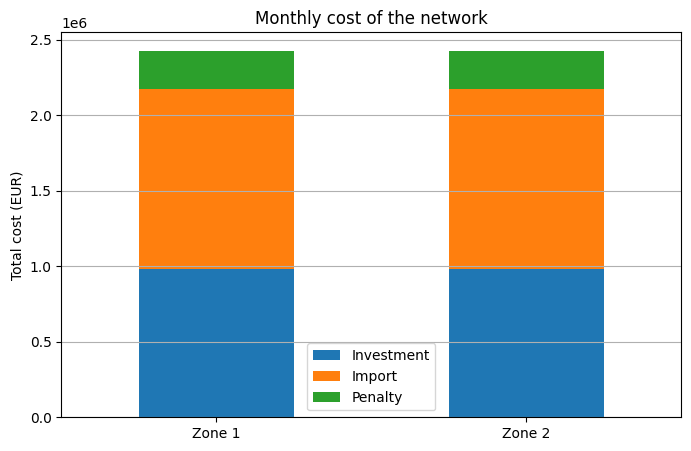


Cost summary (EUR/month)
        Investment      Import    Penalty       Total
Zone 1   981209.90  1191768.26  254695.78  2427673.95
Zone 2   982879.66  1188291.07  254641.45  2425812.18


In [24]:
# Zone 1
import_cost_zone1 = KPI_zone1["imports"] * Import_price
penalty_cost_zone1 = KPI_zone1["unserved demand"] * Unserved_penalty
investment_cost_zone1 = KPI_zone1["objective_EUR"] - import_cost_zone1 - penalty_cost_zone1

# Zone 2
import_cost_zone2 = KPI_zone2["imports"] * Import_price
penalty_cost_zone2 = KPI_zone2["unserved demand"] * Unserved_penalty
investment_cost_zone2 = KPI_zone2["objective_EUR"] - import_cost_zone2 - penalty_cost_zone2

# Dataframe
cost_breakdown = pd.DataFrame({
    "Investment": [investment_cost_zone1, investment_cost_zone2],
    "Import": [import_cost_zone1, import_cost_zone2],
    "Penalty": [penalty_cost_zone1, penalty_cost_zone2]
}, index=["Zone 1", "Zone 2"])

cost_breakdown["Total"] = cost_breakdown.sum(axis=1)
cost_breakdown = cost_breakdown.round(2)

# Plot
cost_breakdown[["Investment", "Import", "Penalty"]].plot(kind="bar", stacked=True, figsize=(8,5))
plt.ylabel("Total cost (EUR)")
plt.title("Monthly cost of the network")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

# Print
print("\nCost summary (EUR/month)")
print(cost_breakdown)


The monthly total system costs are similar in both scenarios, with Case 1 costing 2,427,674 EUR and in Case 2 2,425,812 EUR. Case 1 is therefore slighly more expensive overall. In both cases, imports cost dominate the total system cost, followed by investment costs. Penalty contibutes the least but remains significant. Imports are around 3,500 EUR more expensive in Case 1. 

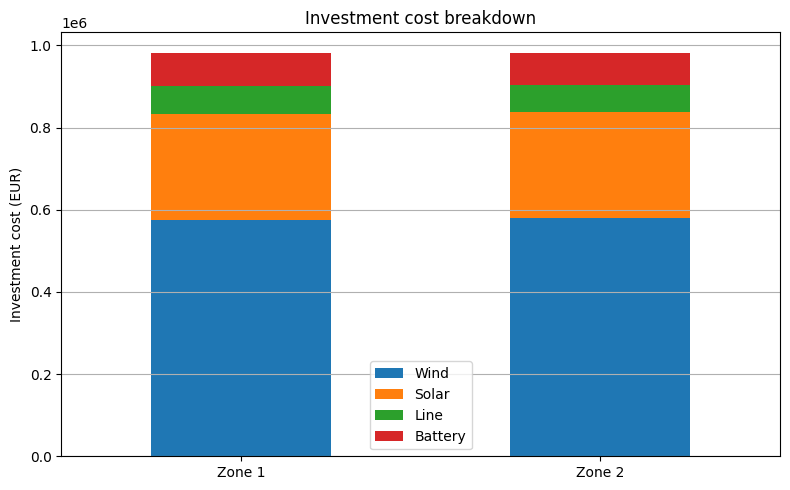


Investment cost summary (EUR/month)
             Wind      Solar      Line   Battery      Total
Zone 1  575487.38  258139.20  67292.22  80291.09  981209.90
Zone 2  579682.64  257542.79  67292.22  78362.01  982879.66


In [25]:
# Zone 1
wind_cost_zone1 = n_zone1.generators.at["wind", "p_nom_opt"] * wind_capital_cost
solar_cost_zone1 = n_zone1.generators.at["solar", "p_nom_opt"] * PV_capital_cost
line_cost_zone1 = n_zone1.links.at["line12", "p_nom_opt"] * line_capital_cost
battery_cost_zone1 = n_zone1.storage_units.at["battery", "p_nom_opt"] * battery_capital_cost

# Zone 2
wind_cost_zone2 = n_zone2.generators.at["wind", "p_nom_opt"] * wind_capital_cost
solar_cost_zone2 = n_zone2.generators.at["solar", "p_nom_opt"] * PV_capital_cost
line_cost_zone2 = n_zone2.links.at["line12", "p_nom_opt"] * line_capital_cost
battery_cost_zone2 = n_zone2.storage_units.at["battery", "p_nom_opt"] * battery_capital_cost


technology_cost = pd.DataFrame({
    "Wind": [wind_cost_zone1, wind_cost_zone2],
    "Solar": [solar_cost_zone1, solar_cost_zone2],
    "Line": [line_cost_zone1, line_cost_zone2],
    "Battery": [battery_cost_zone1, battery_cost_zone2]
}, index=["Zone 1", "Zone 2"])

# Add total
technology_cost["Total"] = technology_cost.sum(axis=1)

# Round
technology_cost = technology_cost.round(2)

# Plot
technology_cost[["Wind", "Solar", "Line", "Battery"]].plot(kind="bar", stacked=True, figsize=(8,5))
plt.ylabel("Investment cost (EUR)")
plt.title("Investment cost breakdown")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

# Print
print("\nInvestment cost summary (EUR/month)")
print(technology_cost)

The investment cost breakdown shows that wind energy represents the largest share of capital investment, follwed by solar, while transmission and battery costs are relatively small.  

The differences between two scenarios are minimal, reflecting that battery location has only limited impact on overall system cost. However, a slighly higher import cost and penalty cost in Case 1 suggest that placing the battery in Zone 2 is more favorable.

##### 5.3 Energy Demand and Supply

In [26]:
gen_zone1 = pd.DataFrame({
    "Wind": n_zone1.generators_t.p["wind"],
    "Solar": n_zone1.generators_t.p["solar"],
    "Imports": n_zone1.generators_t.p["grid_import"]
}).sum()

gen_zone2 = pd.DataFrame({
    "Wind": n_zone2.generators_t.p["wind"],
    "Solar": n_zone2.generators_t.p["solar"],
    "Imports": n_zone2.generators_t.p["grid_import"]
}).sum()

monthly_generation = pd.DataFrame({
    "Zone 1": gen_zone1,
    "Zone 2": gen_zone2
}).T

monthly_generation["Total"] = monthly_generation.sum(axis=1)
monthly_generation = monthly_generation.round(2)
print("\nMonthly generation by source (MWh)")
print(monthly_generation)


Monthly generation by source (MWh)
           Wind    Solar  Imports     Total
Zone 1  7538.93  4578.29  7945.12  20062.34
Zone 2  7707.84  4433.17  7921.94  20062.94


Imports account for the majority of electricity generation, while wind also contributes significantly. Solar contributes roughly half as much as wind and imports, with total generation around 20,000 MWh. 

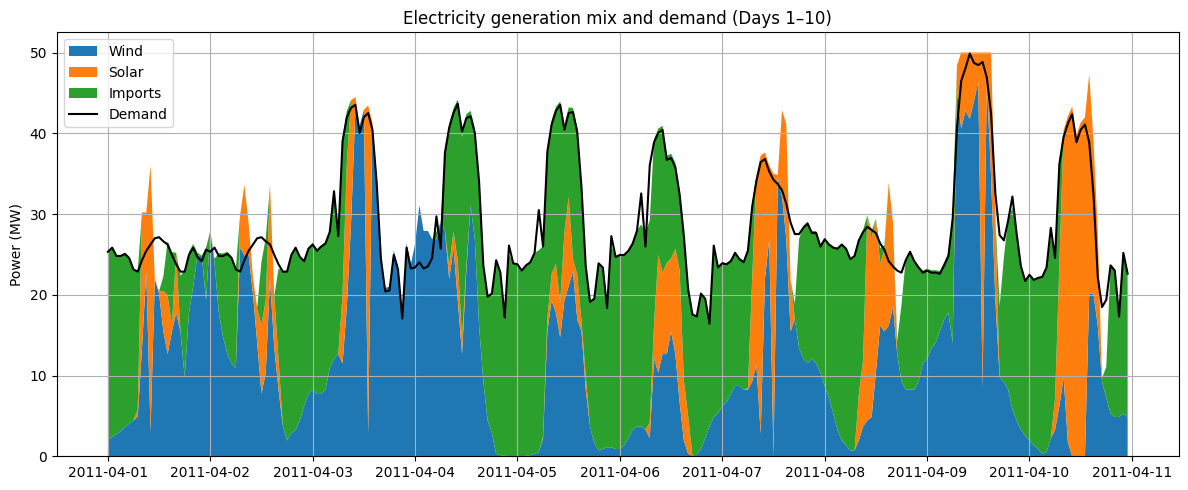

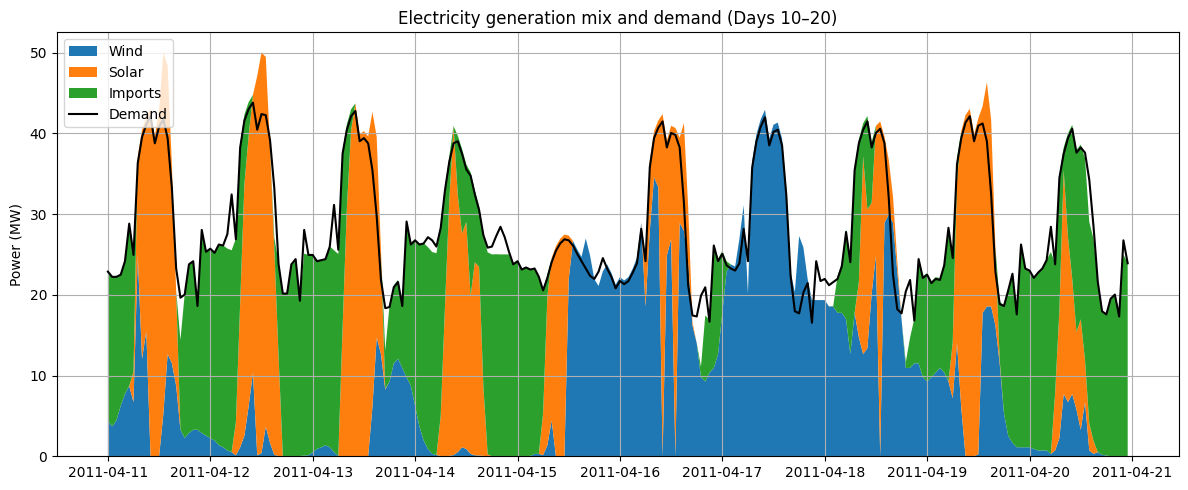

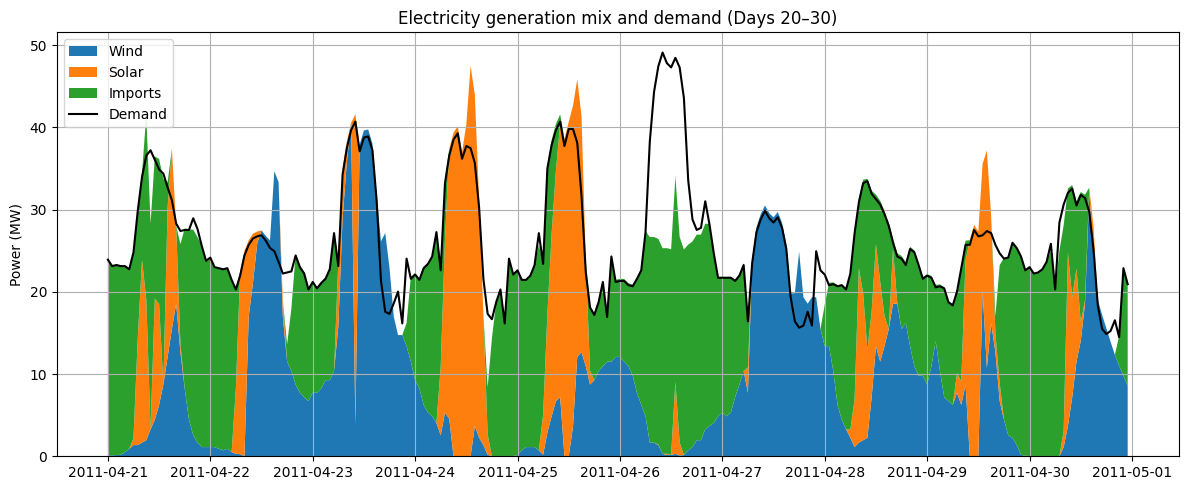

In [27]:
# Change for cases
generation = pd.DataFrame({
    "Wind": n_zone2.generators_t.p["wind"],
    "Solar": n_zone2.generators_t.p["solar"],
    "Imports": n_zone2.generators_t.p["grid_import"]
})

demand_hourly = n_zone2.loads_t.p["demand"]


periods = {
    "Days 1–10": slice("2011-04-01", "2011-04-10 23:00"),
    "Days 10–20": slice("2011-04-11", "2011-04-20 23:00"),
    "Days 20–30": slice("2011-04-21", "2011-04-30 23:00")
}

for title, period in periods.items():
    
    plt.figure(figsize=(12,5))
    
    plt.stackplot(
        generation.loc[period].index,
        generation.loc[period]["Wind"],
        generation.loc[period]["Solar"],
        generation.loc[period]["Imports"],
        labels=["Wind", "Solar", "Imports"]
    )
    
    plt.plot(
        demand_hourly.loc[period].index,
        demand_hourly.loc[period],
        color="black",
        label="Demand"
    )
    
    plt.ylabel("Power (MW)")
    plt.title(f"Electricity generation mix and demand ({title})")
    plt.legend(loc="upper left")
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

During periods with high capacity factors, electricity demand is almost fully supplied by wind and solar. Imports mainly fill the gap during nighttime hours. There are moments when imports, solar, and wind do not fully cover electricity demand, creating gaps that are likely filled by the battery. These gaps mainly occur in the late evening, when demand remains high but generation decreases. In the last 10 days, particularly on the 26th, there is a large portion of demand not covered by generation or imports, which could indicate a potential blackout.

##### 5.4 Curtailment Analysis

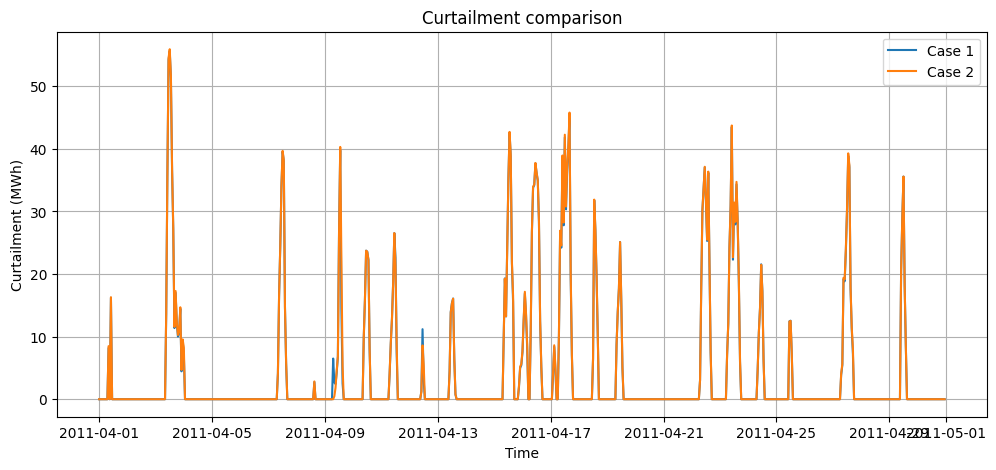


Curtailment summary
        Curtailment (MWh)
Case 1            3017.95
Case 2            3047.04


In [28]:
# Curtailment in Zone 1 scenario
wind_avail_z1 = n_zone1.generators.at["wind", "p_nom_opt"] * np.asarray(capacity_factor_wind).flatten()
solar_avail_z1 = n_zone1.generators.at["solar", "p_nom_opt"] * np.asarray(capacity_factor_solar).flatten()
res_avail_z1 = pd.Series(wind_avail_z1 + solar_avail_z1, index=times_pypsa)
res_gen_z1 = n_zone1.generators_t.p["wind"] + n_zone1.generators_t.p["solar"]
curtailment_z1 = (res_avail_z1 - res_gen_z1).clip(lower=0)

# Curtailment in Zone 2 scenario
wind_avail_z2 = n_zone2.generators.at["wind", "p_nom_opt"] * np.asarray(capacity_factor_wind).flatten()
solar_avail_z2 = n_zone2.generators.at["solar", "p_nom_opt"] * np.asarray(capacity_factor_solar).flatten()
res_avail_z2 = pd.Series(wind_avail_z2 + solar_avail_z2, index=times_pypsa)
res_gen_z2 = n_zone2.generators_t.p["wind"] + n_zone2.generators_t.p["solar"]
curtailment_z2 = (res_avail_z2 - res_gen_z2).clip(lower=0)

plt.figure(figsize=(12,5))

plt.plot(curtailment_z1.index, curtailment_z1, label="Case 1")
plt.plot(curtailment_z2.index, curtailment_z2, label="Case 2")

plt.xlabel("Time")
plt.ylabel("Curtailment (MWh)")
plt.title("Curtailment comparison")
plt.legend()
plt.grid(True)
plt.show()

# Total curtailment
total_curtailment_z1 = curtailment_z1.sum()
total_curtailment_z2 = curtailment_z2.sum()

# Create table
curtailment_summary = pd.DataFrame({
    "Curtailment (MWh)": [total_curtailment_z1, total_curtailment_z2]
}, index=["Case 1", "Case 2"]).round(2)

# Print
print("\nCurtailment summary")
print(curtailment_summary)

Curtailment occurs when available renewable generation exceeds what the system can use or store. In this case, the systemcould have produced more renewable electricity, but constrains such as demand, battery size, prevent it from being used. Economically, this represents a profit loss in this energy.

Curtailment occurs in short spikes rather than continuously, meaning that surplus generation only happens during specific high production periods. The main peaks are around 4th, 17th, and 23rd. These spikes likely correspond to moments with high solar and wind production combined with low demand. Since curtailment is not eliminated, this indicates that the system still lacks sufficient flexibility to fully capitalize on intermittent renewable energy generation.

Both cases show a very similar pattern, suggesting that the location of the battery has limited impact on curtailment. However, there are slight differences in peak values, which might indicate that battery placement can locally absorb excess energy more effectively in certain moments.

##### 5.5 Battery operation analysis

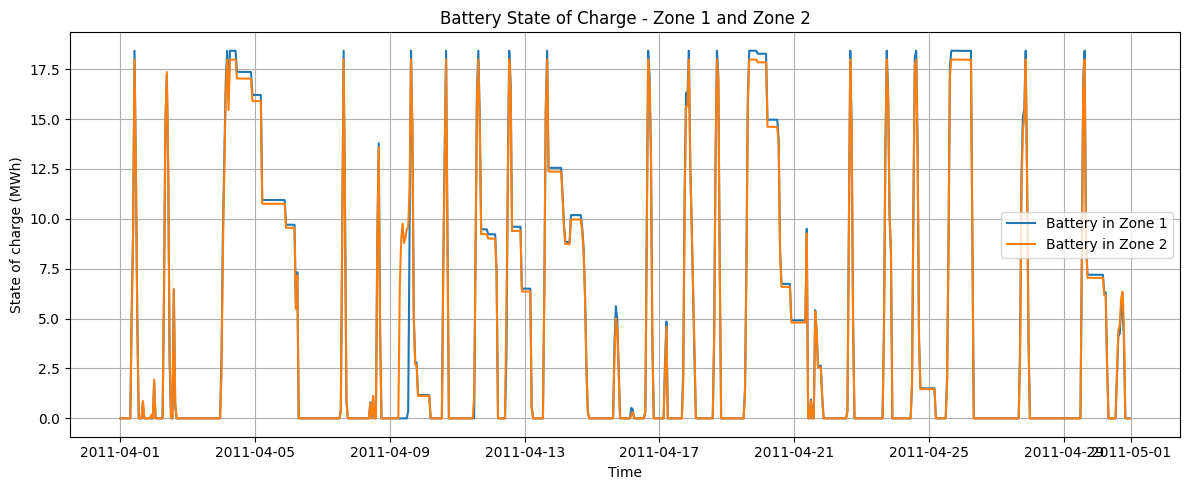


Battery Operation Summary
                         Zone 1  Zone 2 Unit
 Battery power capacity    9.21    8.99   MW
Battery energy capacity   18.42   17.98  MWh
            Maximum SOC   18.42   17.98  MWh
            Minimum SOC   -0.00   -0.00  MWh
         Total charging  415.30  407.46  MWh
      Total discharging  394.65  387.20  MWh


In [29]:
# State of charge (MWh)
soc_z1 = n_zone1.storage_units_t.state_of_charge["battery"]
soc_z2 = n_zone2.storage_units_t.state_of_charge["battery"]

# Battery charging/discharging time series from PyPSA sign convention
# storage_units_t.p > 0  -> battery discharging to the grid
# storage_units_t.p < 0  -> battery charging from the grid
battery_p_z1 = n_zone1.storage_units_t.p["battery"]
battery_p_z2 = n_zone2.storage_units_t.p["battery"]

charge_z1 = (-battery_p_z1).clip(lower=0)
discharge_z1 = battery_p_z1.clip(lower=0)
charge_z2 = (-battery_p_z2).clip(lower=0)
discharge_z2 = battery_p_z2.clip(lower=0)

plt.figure(figsize=(12,5))
plt.plot(soc_z1.index, soc_z1, label="Battery in Zone 1")
plt.plot(soc_z2.index, soc_z2, label="Battery in Zone 2")
plt.xlabel("Time")
plt.ylabel("State of charge (MWh)")
plt.title("Battery State of Charge - Zone 1 and Zone 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Battery operation summary table
battery_summary = pd.DataFrame({
    "": [
        "Battery power capacity",
        "Battery energy capacity",
        "Maximum SOC",
        "Minimum SOC",
        "Total charging",
        "Total discharging"
    ],
    "Zone 1": [
        n_zone1.storage_units.at["battery", "p_nom_opt"],
        n_zone1.storage_units.at["battery", "p_nom_opt"] * n_zone1.storage_units.at["battery", "max_hours"],
        soc_z1.max(),
        soc_z1.min(),
        charge_z1.sum(),
        discharge_z1.sum()
    ],
    "Zone 2": [
        n_zone2.storage_units.at["battery", "p_nom_opt"],
        n_zone2.storage_units.at["battery", "p_nom_opt"] * n_zone2.storage_units.at["battery", "max_hours"],
        soc_z2.max(),
        soc_z2.min(),
        charge_z2.sum(),
        discharge_z2.sum()
    ],
    "Unit": ["MW", "MWh", "MWh", "MWh", "MWh", "MWh"]
})

battery_summary.iloc[:, 1:3] = battery_summary.iloc[:, 1:3].round(2)

print("\nBattery Operation Summary")
print(battery_summary.to_string(index=False))



The lith-ion battery is mainly used to help balance the network and to ensure supply always meets demand. Battery usage peaks at similar times as curtailment, suggesting that is actively participates in stabalizing energy markets. The battery especially helps during late evening and nightime hours, when renewable generation is low. 

Overall, the battery contibutes to improving system balance. However, it is not large enough to reduce curtailment of renewable energy in the system, as there is almost 3000 MWh of lost energy in the month of April.  

##### 5.6 Transmission usage and losses 

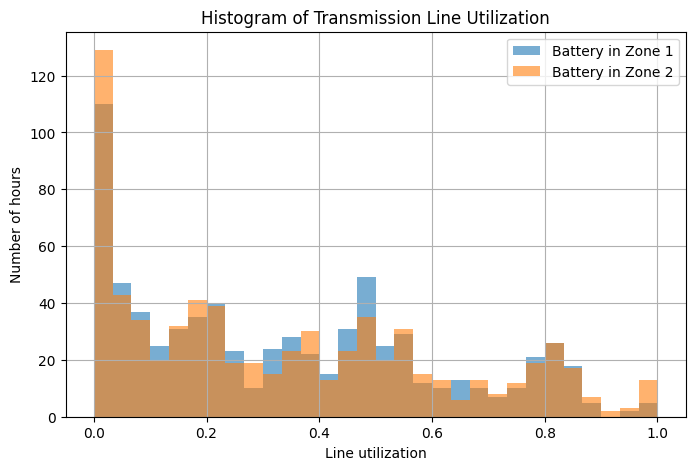

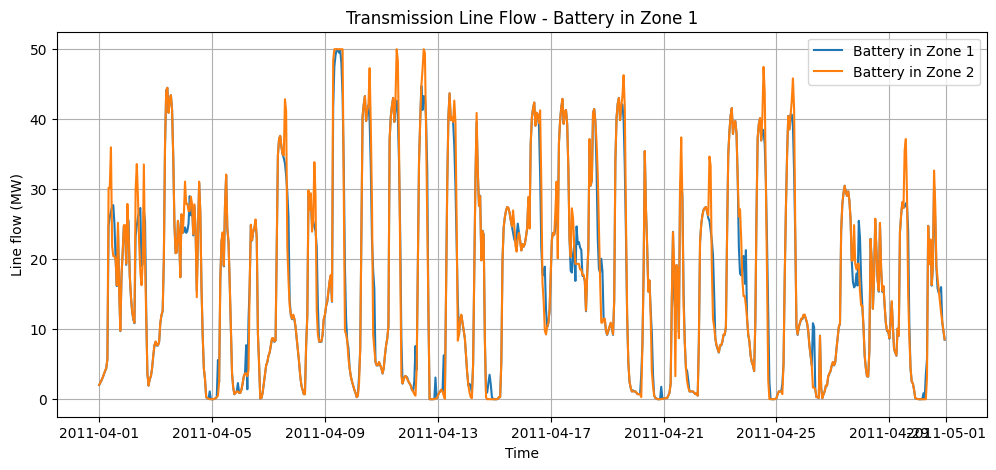


Transmission Usage & Losses Summary
                       Zone 1   Zone 2 Unit
    Total power sent 12096.58 12141.00  MWh
Total power received 11836.50 11879.97  MWh
        Total losses   260.08   261.03  MWh
 Average utilization    33.60    33.73    %


In [30]:
# Line flow time series 
line_flow_z1 = n_zone1.links_t.p0["line12"].abs() 
line_flow_z2 = n_zone2.links_t.p0["line12"].abs()

# Utilization time series (fraction of installed line capacity)
util_z1 = line_flow_z1 / n_zone1.links.at["line12", "p_nom_opt"]
util_z2 = line_flow_z2 / n_zone2.links.at["line12", "p_nom_opt"]

plt.figure(figsize=(8, 5))
plt.hist(util_z1, bins=30, alpha=0.6, label="Battery in Zone 1")
plt.hist(util_z2, bins=30, alpha=0.6, label="Battery in Zone 2")

plt.xlabel("Line utilization")
plt.ylabel("Number of hours")
plt.title("Histogram of Transmission Line Utilization")
plt.legend()
plt.grid(True)
plt.show()

# Zone 1
plt.figure(figsize=(12,5))
plt.plot(line_flow_z1.index, line_flow_z1, label="Battery in Zone 1")
plt.plot(line_flow_z2.index, line_flow_z2, label="Battery in Zone 2")

plt.xlabel("Time")
plt.ylabel("Line flow (MW)")
plt.title("Transmission Line Flow - Battery in Zone 1")
plt.legend()
plt.grid(True)
plt.show()



# Simple summary of transmission KPIs
transmission_summary = pd.DataFrame({
    "": ["Total power sent", "Total power received", "Total losses", "Average utilization"],
    "Zone 1": [
        line_flow_z1.sum(),
        line_flow_z1.sum() * n_zone1.links.at["line12", "efficiency"],
        line_flow_z1.sum() * (1 - n_zone1.links.at["line12", "efficiency"]),
        util_z1.mean() * 100
    ],
    "Zone 2": [
        line_flow_z2.sum(),
        line_flow_z2.sum() * n_zone2.links.at["line12", "efficiency"],
        line_flow_z2.sum() * (1 - n_zone2.links.at["line12", "efficiency"]),
        util_z2.mean() * 100
    ],
    "Unit": ["MWh", "MWh", "MWh", "%"]
})

transmission_summary.iloc[:, 1:3] = transmission_summary.iloc[:, 1:3].round(2)

print("\nTransmission Usage & Losses Summary")
print(transmission_summary.to_string(index=False))

Overall, these results show that the transmission line is not a major bottleneck in the system. The time series and histogram indicate that the line is often lightly loaded, with only short periods of higher utilization, and it rarely operates close to full capacity for extended periods. The cable is relatively cheap in terms of capital costs, so it makes sense to install a larger capacity. Battery location has minimal impact on transmission usage. The transmission line usage is very similar in both scenarios. Total power sent is slightly higher Case 2 compared to Case 2, while total losses are nearly identical at around 260 MWh in both cases. The average utilization is also almost the same, with 33.60% in Case 1 and 33.73% in Case 2, indicating that the line is used at 1/3 of its capacity on average.

##### 5.6 Reliability (unserved demand)

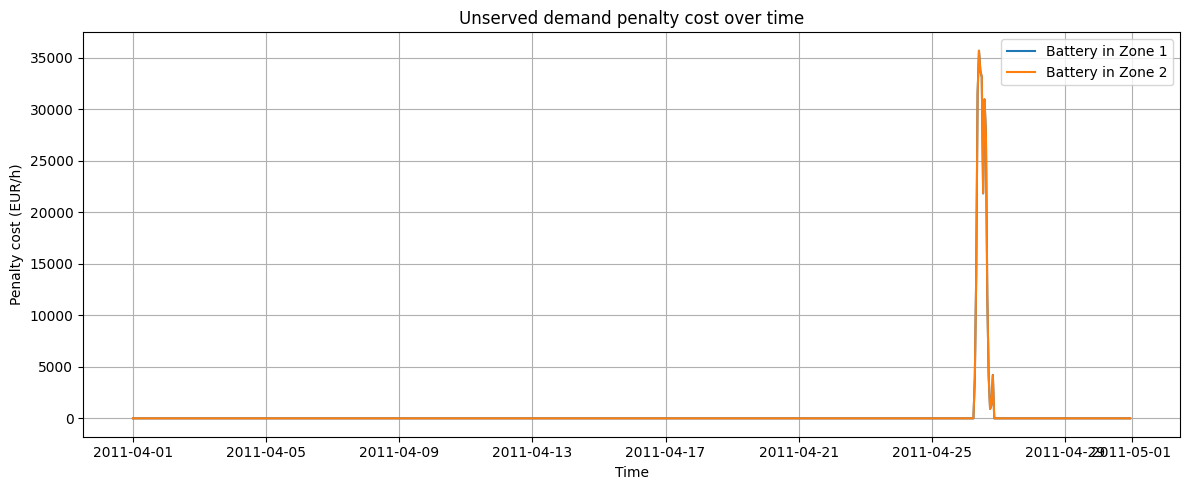


Unserved demand summary
        Unserved demand (MWh)  Penalty cost (EUR)
Zone 1                 169.80           254695.78
Zone 2                 169.76           254641.45


In [31]:
# Lost-load time series (MWh/h = MW over one-hour snapshots)
lost_load_zone1 = n_zone1.generators_t.p["lost_load"]
lost_load_zone2 = n_zone2.generators_t.p["lost_load"]

# Hourly penalty cost
penalty_cost_flow_zone1 = lost_load_zone1 * Unserved_penalty
penalty_cost_flow_zone2 = lost_load_zone2 * Unserved_penalty

# Plot
plt.figure(figsize=(12,5))
plt.plot(penalty_cost_flow_zone1.index, penalty_cost_flow_zone1, label="Battery in Zone 1")
plt.plot(penalty_cost_flow_zone2.index, penalty_cost_flow_zone2, label="Battery in Zone 2")
plt.xlabel("Time")
plt.ylabel("Penalty cost (EUR/h)")
plt.title("Unserved demand penalty cost over time")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Compute totals
total_lost_load_zone1 = lost_load_zone1.sum()
total_lost_load_zone2 = lost_load_zone2.sum()

# Compute penalty costs
penalty_zone1 = total_lost_load_zone1 * Unserved_penalty
penalty_zone2 = total_lost_load_zone2 * Unserved_penalty

# Create summary table
lost_load_summary = pd.DataFrame({
    "Unserved demand (MWh)": [total_lost_load_zone1, total_lost_load_zone2],
    "Penalty cost (EUR)": [penalty_zone1, penalty_zone2]
}, index=["Zone 1", "Zone 2"]).round(2)

print("\nUnserved demand summary")
print(lost_load_summary)



As expected, on the 26th there is a large amount of unserved demand, as renewable generation on that day was minimal. Imports were maximized and the battery was operating at its peak, but this was still insufficient. This resulted in a blackout of around 170 MWh, leading to a penalty cost of €254,700. The blackout occurred during the day and lasted approximately one day.

##### 5.7 Disscussion